## This notebook runs on one configuration (NOFLAG) and genertes the simulated data, It also estimates the power spectrum from the input data and plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts
import os
plt.style.use("mplstyle")

In [2]:
# input model power spectrum
n = 2.0
N = 768
dnuc = 40e-3            # MHz
r = 9209.714526830916 # Mpc
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 5

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
k_model = PK21[:, 0]
P_model = PK21[:, 1]
# P_model = k_model**(-n)


k_fft = 2*np.pi*np.arange(N)/L

# kper = 0.1
# k_fft = np.sqrt( k_fft**2 + kper**2 ) 

k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model , left=0, right=0)

# Discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont 
# P_dft = L * P_cont 
# P_dft = P_cont 

# binning 
NB = 64  # number of bins
NN_gp = 96
NN_gp = 16

In [3]:
(N**2 / L), (N / dL),  (N * dL),  (L), dL

(1130.082533147537,
 1130.0825331475373,
 521.9300207722049,
 521.9300207722049,
 0.6795963812138084)

In [4]:
# INP_SIGNAL_CONFIGS = {
#     "21cm": dict(type="21cm"),
#     "FG+21cm": dict(type="FG+21cm"),
#     "FG+MM+21cm": dict(type="FG+MM+21cm"),
# }
INP_SIGNAL_CONFIGS = {
    # "21cm": dict(type="21cm"),
    "FG+MM+21cm": dict(type="FG+MM+21cm"),
}

# # -----------------------------
# # FLAG configurations
# # -----------------------------
# FLAG_CONFIGS = {
#     "NOFLAG": dict(mode="NOFLAG", percent=0, seed=42),
#     "RANDOM35": dict(mode="RANDOM", percent=35, seed=42),
#     "PERIODIC": dict(mode="PERIODIC", percent=0, seed=42),
#     "PERIODIC+RANDOM10": dict(mode="PERIODIC+RANDOM", percent=10, seed=42),
# }
FLAG_CONFIGS = {
    "NOFLAG": dict(mode="NOFLAG", percent=0, seed=42),
}

# # -----------------------------
# # SCF configurations
# # -----------------------------
# SCF_CONFIGS = {
#     "None": dict(SCF="None", NN_gp=None, NN_hann=None),
#     "GP":   dict(SCF="GP",   NN_gp=96,  NN_hann=None),
#     "Hann": dict(SCF="Hann", NN_gp=None, NN_hann=50),
# }

SCF_CONFIGS = {
    "GP":   dict(SCF="GP",   NN_gp=NN_gp,  NN_hann=None),
}


In [5]:
def generate_fields(inp_signal, *, N, Nrea, P_dft):
    # 21-cm realizations (always needed)
    fields_21cm = np.array(
        [pfunc.draw_field_from_power(P_dft, seed=55 + i) for i in range(Nrea)]
    )

    if inp_signal == "21cm":
        return fields_21cm

    if inp_signal == "FG+21cm":
        fields_forg = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=1e4,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1, seed=42,
        )
        return fields_forg + fields_21cm

    if inp_signal == "FG+MM+21cm":
        fields_forg = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=100,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1, seed=42,
        )
        return fields_forg + fields_21cm

    raise ValueError(f"Unknown inp_signal: {inp_signal}")


In [6]:
def run_one_configuration(
    fields_tota,
    inp_signal,
    flag_cfg,
    scf_cfg,
    *,
    N, L, dL, r, NB,
    k_model, P_model,
    P_cont, k_abs,
    path="results"
):
    # -----------------------------
    os.makedirs(path, exist_ok=True)
    # -----------------------------
    flag = pfunc.flagdata(
        N,
        mode=flag_cfg["mode"],
        percent=flag_cfg["percent"],
        seed=flag_cfg["seed"],
    )

    flag_percent = 100 * (1 - np.count_nonzero(flag) / N)
    print(
        f"[FLAG={flag_cfg['mode']}, SCF={scf_cfg['SCF']}] "
        f"flagged = {flag_percent:.1f}%"
    )

    # -----------------------------
    # SCF processing
    # -----------------------------
    fields_orig, fields_flag, ml = pfunc.process_scf(
        fields_tota,
        flag,
        scf_cfg["SCF"],
        NN_gp=scf_cfg["NN_gp"],
        NN_hann=scf_cfg["NN_hann"],
    )
    
    # plt.plot(fields_orig[0])
    # plt.show()
    
    # -----------------------------
    # FFT estimator
    # -----------------------------
    pk_fft = pfunc.pk_fft(fields_flag, L, N)

    n1_fft, nend_fft = 0, N // 2
    kb_fft, mean_fft, err_fft, binned_th_fft, _ = pfunc.bin_power_spectrum(
        n1_fft, nend_fft,
        k_abs[n1_fft:nend_fft],
        pk_fft,
        P_cont,
        NB
    )

    # -----------------------------
    # DCT estimator
    # -----------------------------
    M = np.argmax(ml.real == 0) if np.any(ml.real == 0) else ml.shape[0]
    k_dct = np.pi * np.arange(M) / ((M - 1) * dL)
    # print(k_dct)
    
    P_cont_dct = np.interp(k_dct, k_model, P_model, left=0, right=0)
    w = windows.nuttall(2*M)[M:]
    pk_dct, cl = pfunc.pk_dct(fields_flag, dL, ml, M, r, w)

    kb_dct, mean_dct, err_dct, binned_th_dct, _ = pfunc.bin_power_spectrum(
        0, M, k_dct, pk_dct, P_cont_dct, NB
    )

    # -----------------------------
    # Save outputs
    # -----------------------------
    flag_name = flag_cfg["mode"]
    SCF = scf_cfg["SCF"]

    # Construct filename matching your save_data style
    fields_fname = f"{path}/fields_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}.npz"

    # Only save if the file does not exist
    # if not os.path.exists(fields_fname):
    # print(f"Saving fields to {fields_fname}...")
    np.savez(
        fields_fname,
        fields_tota=fields_tota,
        fields_orig=fields_orig,
        fields_flag=fields_flag,
        # Metadata (optional but helpful)
        inp_signal=inp_signal,
        flag=flag_name,
        SCF=SCF
    )

    pfunc.save_data(
        f"{path}/fft",
        inp_signal=inp_signal,
        flag=flag_name,
        SCF=SCF,
        kb=kb_fft,
        mean=mean_fft,
        err=err_fft,
        binned_th=binned_th_fft,
    )

    pfunc.save_data(
        f"{path}/dct",
        inp_signal=inp_signal,
        flag=flag_name,
        SCF=SCF,
        kb=kb_dct,
        mean=mean_dct,
        err=err_dct,
        binned_th=binned_th_dct,
    )

    np.savez(
        f"{path}/CL_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}.npz",
        cl=cl,
        inp_signal=inp_signal,
        flag=flag,
        SCF=SCF,
    )



In [7]:
# from tqdm.notebook import tqdm  # Use 'tqdm' if running in a script
from tqdm import tqdm

# Wrap your outer loop with tqdm
for inp_signal in tqdm(INP_SIGNAL_CONFIGS, desc="Signals"):

    print(f"\n=== Running inp_signal = {inp_signal} ===")
    
    fields_tota = generate_fields(
        inp_signal,
        N=N, Nrea=Nrea, P_dft=P_dft,
    )

    

    # You can also wrap inner loops if they are long
    for flag_key, flag_cfg in FLAG_CONFIGS.items():
        for scf_key, scf_cfg in SCF_CONFIGS.items():
            
            run_one_configuration(
                fields_tota=fields_tota,
                inp_signal=inp_signal,
                flag_cfg=flag_cfg,
                scf_cfg=scf_cfg,
                N=N, L=L, dL=dL, r=r, NB=NB,
                k_model=k_model,
                P_model=P_model,
                P_cont=P_cont,
                k_abs=k_abs,
                path="results_test",
            )


Signals:   0%|                                                                                    | 0/1 [00:00<?, ?it/s]


=== Running inp_signal = FG+MM+21cm ===
[FLAG=NOFLAG, SCF=GP] flagged = 0.0%
[(None, None), (None, None), (np.float64(0.0), np.float64(5.545177444479562))]
[(None, None), (None, None), (np.float64(0.0), np.float64(5.545177444479562))]
[(None, None), (None, None), (np.float64(0.0), np.float64(5.545177444479562))]
[(None, None), (None, None), (np.float64(0.0), np.float64(5.545177444479562))]
[(None, None), (None, None), (np.float64(0.0), np.float64(5.545177444479562))]


Signals: 100%|████████████████████████████████████████████████████████████████████████████| 1/1 [00:08<00:00,  8.06s/it]


In [8]:
def FGname(inp_signal):
    if (inp_signal == '21cm'):
        FG = 'None'
        dataname = '21cm'
    elif (inp_signal == 'FG+21cm'):
        FG = 'Smooth'
        dataname = 'FG'
    elif (inp_signal == 'FG+MM+21cm'):
        FG = 'Unsmooth'
        dataname = 'FGMM'
    return FG, dataname

inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
Saved: plots/FGMM_GP_allflags.pdf


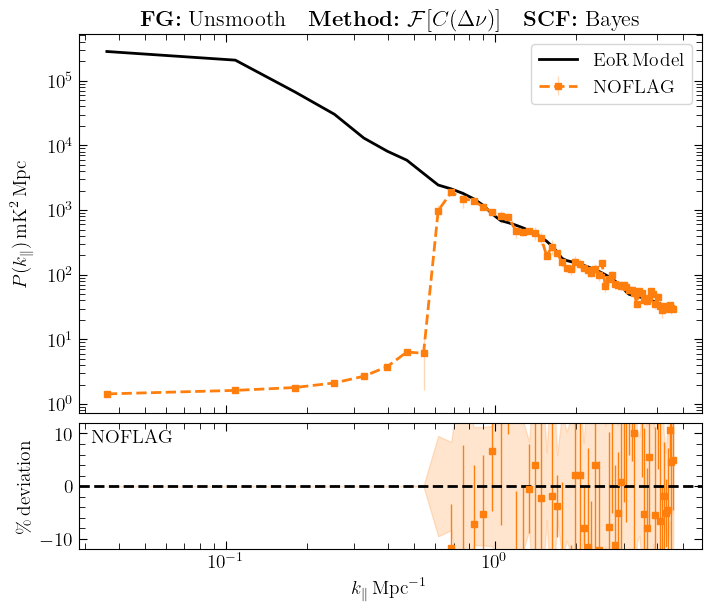

In [11]:
inp_signal = "21cm"
inp_signal = "FG+MM+21cm"
SCF        = "GP"
path       = "results_test"
modes  = ['NOFLAG']
colors = ['C1']
fmts = ['s']

FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210
 
figname = f"plots/{dataname}_{SCF}_allflags.pdf"
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------
fig = plt.figure(figsize=(7, 6))
gs  = fig.add_gridspec(
    2, 1,
    height_ratios=[3, 1],
    hspace=0.02
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 2)]

# --------------------------------------------------
# LOOP OVER FLAG PATTERNS
# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        abs(mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),  # transparent error bars
        label=fr"$\rm{{ {mode} }}$" 

    )


    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )

    axd[i].fill_between(kb_fft, -err_r, err_r,
                        color=color, alpha=0.2,
                        label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    # axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')
    axd[i].set_xscale('log')

    axd[i].text(
        0.02, 0.85,
        fr"$\rm{{ {mode} }}$",
        transform=axd[i].transAxes,
        # fontsize=10
    )

    if ylim is not None:
        axd[i].set_ylim(-ylim, ylim)
    axd[0].set_ylim(-12, 12)

    
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\,{\rm Mpc}$')
# ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].tick_params(labelbottom=True)


axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

SCF = 'Bayes'
ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"\rm{{{FG}}}"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
    
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)
